In [1]:
import numpy as np
import ase
from ase.build import graphene, make_supercell
from mace.calculators import MACECalculator
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter

from energy_vs_amplitude import *

from ase.visualize import view

from ase import Atom, Atoms

/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

model_path = f"{ROOT}/KAGGLE_DOWNLOAD/from_C2_v1/MACE.model"
model = MACECalculator(model_path=model_path, device="cuda")

/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.


/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [3]:
pristine = graphene()
pristine.cell[2,2] = 100
pristine.calc = model

filter = FrechetCellFilter(pristine, mask = [1,1,0,0,0,0])
opt = BFGS(filter, logfile = None)
opt.run(1e-5)

supercell = make_supercell(pristine, np.diag((3, 3, 1)))

In [4]:
DEG2RAD = np.pi/180

angle = 45
rot = 0
amplitude = 0.23

C = np.cos(angle * DEG2RAD)
S = np.sin(angle * DEG2RAD)

Cr = np.cos(rot * DEG2RAD)
Sr = np.sin(rot * DEG2RAD)

ROT = np.array([
    [Cr, -Sr, 0],
    [Sr, Cr, 0],
    [0, 0, 1]
])


strain_versor = np.array([
    [C, 0, 0],
    [0, S, 0],
    [0, 0, 0]
])
strain = amplitude * strain_versor
deformation = np.eye(3) + strain


In [5]:
import itertools
import numpy as np

# =====================================================================
# 1. Base Cartesian conversions tailored to your new sign shifts
# =====================================================================
# Eq 1 & 3
X0x = np.cos(np.pi / 6)
Y0x = (X0x * np.cos(2 * np.pi / 3)) / np.sin(2 * np.pi / 3)

# Eq 2 & 4 (Sign flipped on the constant term)
X0y = np.sin(np.pi / 6)
Y0y = (X0y * np.cos(2 * np.pi / 3) + 1) / np.sin(2 * np.pi / 3)

# Eq 5 & 7 (Sign flipped on the constant term)
X1x = -np.cos(np.pi / 6)
Y1x = (X1x * np.cos(2 * np.pi / 3) - np.sin(np.pi / 6)) / np.sin(2 * np.pi / 3)

# Eq 6 & 8 (Sign flipped on the constant term)
X1y = -np.sin(np.pi / 6)
Y1y = (X1y * np.cos(2 * np.pi / 3) + np.cos(np.pi / 6)) / np.sin(2 * np.pi / 3)

# =====================================================================
# 2. Generator function to construct both (+rho) and (-rho) branches
# =====================================================================
def get_branches(X, Y):
    r = np.sqrt(X**2 + Y**2)
    p = np.arctan2(Y, X)
    # Mirror branch shifted by pi and bound within [-pi, pi]
    p_neg = p + np.pi if p <= 0 else p - np.pi
    return [(r, p), (-r, p_neg)]

s0x = get_branches(X0x, Y0x)
s0y = get_branches(X0y, Y0y)
s1x = get_branches(X1x, Y1x)
s1y = get_branches(X1y, Y1y)

# =====================================================================
# 3. Create combinations matrix of shape (16, 8)
# =====================================================================
combinations = list(itertools.product(s0x, s0y, s1x, s1y))
solution_array = np.zeros((16, 8))

for idx, comb in enumerate(combinations):
    solution_array[idx] = [
        comb[0][0], comb[0][1],  # rho0x, phi0x
        comb[1][0], comb[1][1],  # rho0y, phi0y
        comb[2][0], comb[2][1],  # rho1x, phi1x
        comb[3][0], comb[3][1]   # rho1y, phi1y
    ]

# =====================================================================
# EXAMPLE RUN: Control indexing here (0 to 15)
# =====================================================================
my_index = 1

rho0x, phi0x, rho0y, phi0y, rho1x, phi1x, rho1y, phi1y = solution_array[my_index]

print(f"--- Parameters Unpacked from Index {my_index} ---")
print(f"rho0x = {rho0x: .4f}, phi0x = {phi0x: .4f}")
print(f"rho0y = {rho0y: .4f}, phi0y = {phi0y: .4f}")
print(f"rho1x = {rho1x: .4f}, phi1x = {phi1x: .4f}")
print(f"rho1y = {rho1y: .4f}, phi1y = {phi1y: .4f}\n")

print("--- Verifying New Equations (All should read 0) ---")
print(f"Eq 1: {rho0x * np.cos(phi0x) - np.cos(np.pi/6): .1e}")
print(f"Eq 2: {rho0y * np.cos(phi0y) - np.sin(np.pi/6): .1e}")
print(f"Eq 3: {rho0x * np.cos(phi0x + (2 * np.pi/3)): .1e}")
print(f"Eq 4: {rho0y * np.cos(phi0y + (2 * np.pi/3)) + 1: .1e}")
print(f"Eq 5: {rho1x * np.cos(phi1x) + np.cos(np.pi/6): .1e}")
print(f"Eq 6: {rho1y * np.cos(phi1y) + np.sin(np.pi/6): .1e}")
print(f"Eq 7: {rho1x * np.cos(phi1x + (2 * np.pi/3)) - np.sin(np.pi/6): .1e}")
print(f"Eq 8: {rho1y * np.cos(phi1y + (2 * np.pi/3)) + np.cos(np.pi/6): .1e}")

--- Parameters Unpacked from Index 1 ---
rho0x =  1.0000, phi0x = -0.5236
rho0y =  1.0000, phi0y =  1.0472
rho1x =  0.8695, phi1x = -3.0525
rho1y = -1.3823, phi1y = -1.2007

--- Verifying New Equations (All should read 0) ---
Eq 1:  0.0e+00
Eq 2: -5.6e-17
Eq 3:  6.1e-17
Eq 4:  0.0e+00
Eq 5:  1.1e-16
Eq 6: -5.6e-17
Eq 7:  0.0e+00
Eq 8: -1.1e-16


In [6]:
mode = np.array([
    [rho0x * np.exp(1j*phi0x), rho0y*np.exp(1j*phi0y), 0],
    [rho1x * np.exp(1j*phi1x), rho1y*np.exp(1j*phi1y), 0],
])

norm = np.linalg.norm(mode, axis = -1)
# mode[0] /= norm[0]
# mode[1] /= norm[1]

kpoint = np.array([1/3, 1/3, 0])
amplitudes = np.linspace(-0.5, 0.5, 100)

WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 3.530e-05*i)
WARNING, 1 imaginary frequencies at q = ( 0.36,  0.28,  0.00) ; (omega_q = 7.088e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.36,  0.29,  0.00) ; (omega_q = 1.077e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.35,  0.29,  0.00) ; (omega_q = 1.314e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.35,  0.30,  0.00) ; (omega_q = 1.485e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.35,  0.31,  0.00) ; (omega_q = 1.611e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.34,  0.31,  0.00) ; (omega_q = 1.702e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.34,  0.32,  0.00) ; (omega_q = 1.763e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.34,  0.33,  0.00) ; (omega_q = 1.799e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.33,  0.33,  0.00) ; (omega_q = 1.811e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.33,  0.33,  0.00) ; (omega_q = 1.800e-01*i)
WARNING, 1 imaginary frequencies

(-0.021707814223615927, 0.12903904978545766)

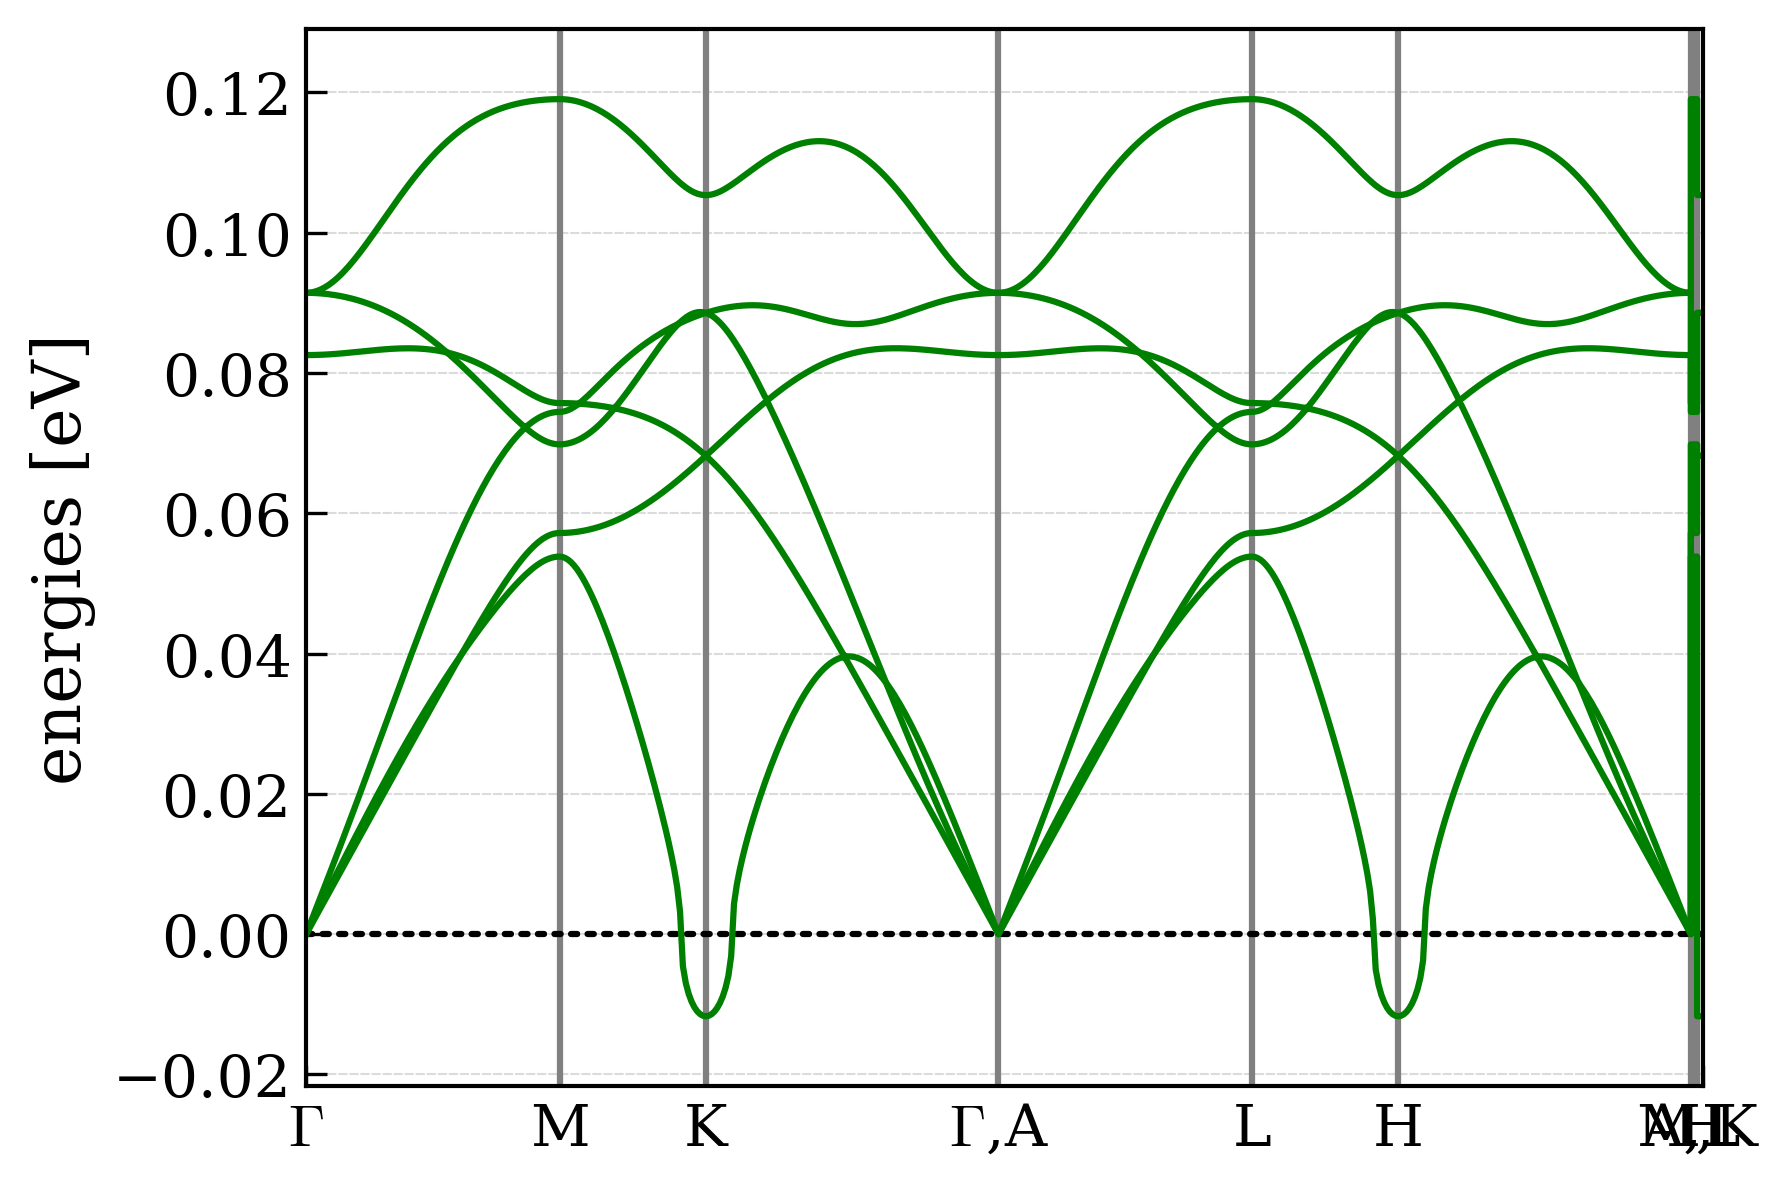

In [7]:
from ase.phonons import Phonons

deformed = pristine.copy()

deformed.set_cell(pristine.cell @ deformation, scale_atoms = True)

deformed.calc = model


ph = Phonons(
    deformed,
    model,
    supercell = (9, 9, 1),
    delta = 0.01,
    name="cache"
)

ph.run()

ph.read(acoustic=True)
ph.clean()

path = deformed.cell.bandpath()
path = path.interpolate(npoints = 500)

bs, modes = ph.get_band_structure(path, modes=True)

bs.plot()
min = np.min(bs.energies)-0.01
max = np.max(bs.energies)+0.01
plt.ylim(min, max)



In [8]:
energies = bs.energies[0] # Shape: (N_kpoints, N_modes)
min_idx = np.argmin(energies)
kidx = min_idx // 6
mode_idx = min_idx % 6
ase_mode = modes[kidx, mode_idx]
kpoint = path.kpts[kidx]
energy = energies[kidx, mode_idx]

In [9]:
norm_mode = mode / np.linalg.norm(mode)
norm_ase_mode = ase_mode / np.linalg.norm(ase_mode)

In [10]:
np.vdot(norm_ase_mode, norm_mode)

np.complex128(-0.07540790848131995+0.11596304110791839j)

In [11]:
R_T = np.linalg.pinv(norm_ase_mode) @ norm_mode

# R_T will be a 3x3 complex matrix
print("Transformation Matrix (R^T):\n", R_T)

# Test the transformation
transformed_mode = norm_ase_mode @ R_T

Transformation Matrix (R^T):
 [[-5.00959857e-01-3.03530156e-01j -7.27579011e-01-5.55439056e-01j
   0.00000000e+00+0.00000000e+00j]
 [-4.95715681e-01-4.04672864e-01j  3.50231948e-01+5.35553588e-01j
   0.00000000e+00+0.00000000e+00j]
 [-3.44317703e-05+2.77912268e-06j -2.64746435e-05+5.40008156e-05j
   0.00000000e+00+0.00000000e+00j]]


In [23]:
np.linalg.norm(norm_mode - transformed_mode)

np.float64(5.74211813252823e-16)

In [25]:
k = np.array([1/3, 1/3, 0])
D_k = ph.compute_dynamical_matrix(k, ph.D_N)

In [45]:
D_k_reshaped = D_k.reshape(2, 3, 2, 3)

import numpy as np

# D_k_reshaped has indices: i (atom1), a (cart1), j (atom2), b (cart2)
# R_T has indices acting on Cartesian space

# Term 1: Apply R_T to both the row (a) and column (b) Cartesian indices
# This represents R * D * R_adj
# 'ac' acts on the row index 'a' -> becomes 'c'
# 'bd' acts on the column index 'b' -> becomes 'd'
R_T_adj = R_T.conj().T

D_transformed = np.einsum("ab, de, ibjd -> iaje", R_T, R_T_adj, D_k_reshaped)

# Term 2: The original untransformed dynamical matrix
D_original = D_k_reshaped

# Check the residual norm between the transformed and original matrix
symmetry_residual = np.linalg.norm(D_transformed - D_original)
print("Symmetry Commutation Residual Norm:", symmetry_residual)

Symmetry Commutation Residual Norm: 3.4297861970787666


In [13]:
import numpy as np

magnitudes = np.abs(R_T)
print("Magnitudes:\n", magnitudes)
print("magnitudes moduluses", np.linalg.norm(magnitudes, axis=-1))

phases = np.degrees(np.angle(R_T))
print("\nPhases (Degrees):\n", phases)

Magnitudes:
 [[5.85739989e-01 9.15359909e-01 0.00000000e+00]
 [6.39917310e-01 6.39906293e-01 0.00000000e+00]
 [3.45437452e-05 6.01414569e-05 0.00000000e+00]]
magnitudes moduluses [1.08672678e+00 9.04971948e-01 6.93560752e-05]

Phases (Degrees):
 [[-148.78844666 -142.64162518    0.        ]
 [-140.77384023   56.81681998    0.        ]
 [ 175.38543735  116.11703964    0.        ]]


In [22]:
# Extract the phase of the first element
global_phase = np.angle(R_T[0, 0])

# "De-phase" the matrix
R_dephased = R_T * np.exp(-1j * global_phase)

print(f"Global Phase Shift: {np.degrees(global_phase):.2f} degrees")
print("\nDe-phased Matrix (Should be mostly Real numbers):")
print(R_dephased)

print("\nResidual Imaginary Parts (Should be near 0):")
print(np.imag(R_dephased).round(4))

print("\nResidual Phases")
print(np.angle(R_dephased))

Global Phase Shift: -148.79 degrees

De-phased Matrix (Should be mostly Real numbers):
[[ 5.85739989e-01+8.96337784e-17j  9.10097298e-01+9.80136248e-02j
  -0.00000000e+00+0.00000000e+00j]
 [ 6.33666954e-01+8.92208203e-02j -5.77062891e-01-2.76547435e-01j
  -0.00000000e+00+0.00000000e+00j]
 [ 2.80079686e-05-2.02193973e-05j -5.34049650e-06-5.99038724e-05j
  -0.00000000e+00+0.00000000e+00j]]

Residual Imaginary Parts (Should be near 0):
[[ 0.000e+00  9.800e-02  0.000e+00]
 [ 8.920e-02 -2.765e-01  0.000e+00]
 [-0.000e+00 -1.000e-04  0.000e+00]]

Residual Phases
[[ 1.53026565e-16  1.07282273e-01  3.14159265e+00]
 [ 1.39881271e-01 -2.69469644e+00  3.14159265e+00]
 [-6.25283682e-01 -1.65971236e+00  3.14159265e+00]]


In [15]:
# Flatten the (2, 3) arrays to (6,) vectors
ase_mode_0_flat = norm_ase_mode.flatten() # Degenerate mode 1
ase_mode_1_flat = np.conj(norm_ase_mode.flatten()) # Degenerate mode 2
target_flat = norm_mode.flatten()

# Stack them to build the true degenerate subspace matrix (Shape: 6 x 2)
subspace = np.column_stack((ase_mode_0_flat, ase_mode_1_flat))

# Find the 2 complex mixing coefficients
coefficients = np.linalg.pinv(subspace) @ target_flat

print("Complex Mixing Coefficients (c1, c2):", coefficients)
print("Reconstruction Fidelity (Should be near 1.0):", np.linalg.norm(subspace @ coefficients))

Complex Mixing Coefficients (c1, c2): [-0.07538016+0.11600579j -0.54382807+0.80425064j]
Reconstruction Fidelity (Should be near 1.0): 0.9806639777327121


In [16]:
supercells, energies = energy_mode(
    pristine, 
    strain_versor, 
    amplitude, 
    np.array([3, 3, 1]),
    model,
    np.array([kpoint]), 
    np.array([mode]) / np.linalg.norm(mode), 
    np.array([1]),
    amplitudes
    )

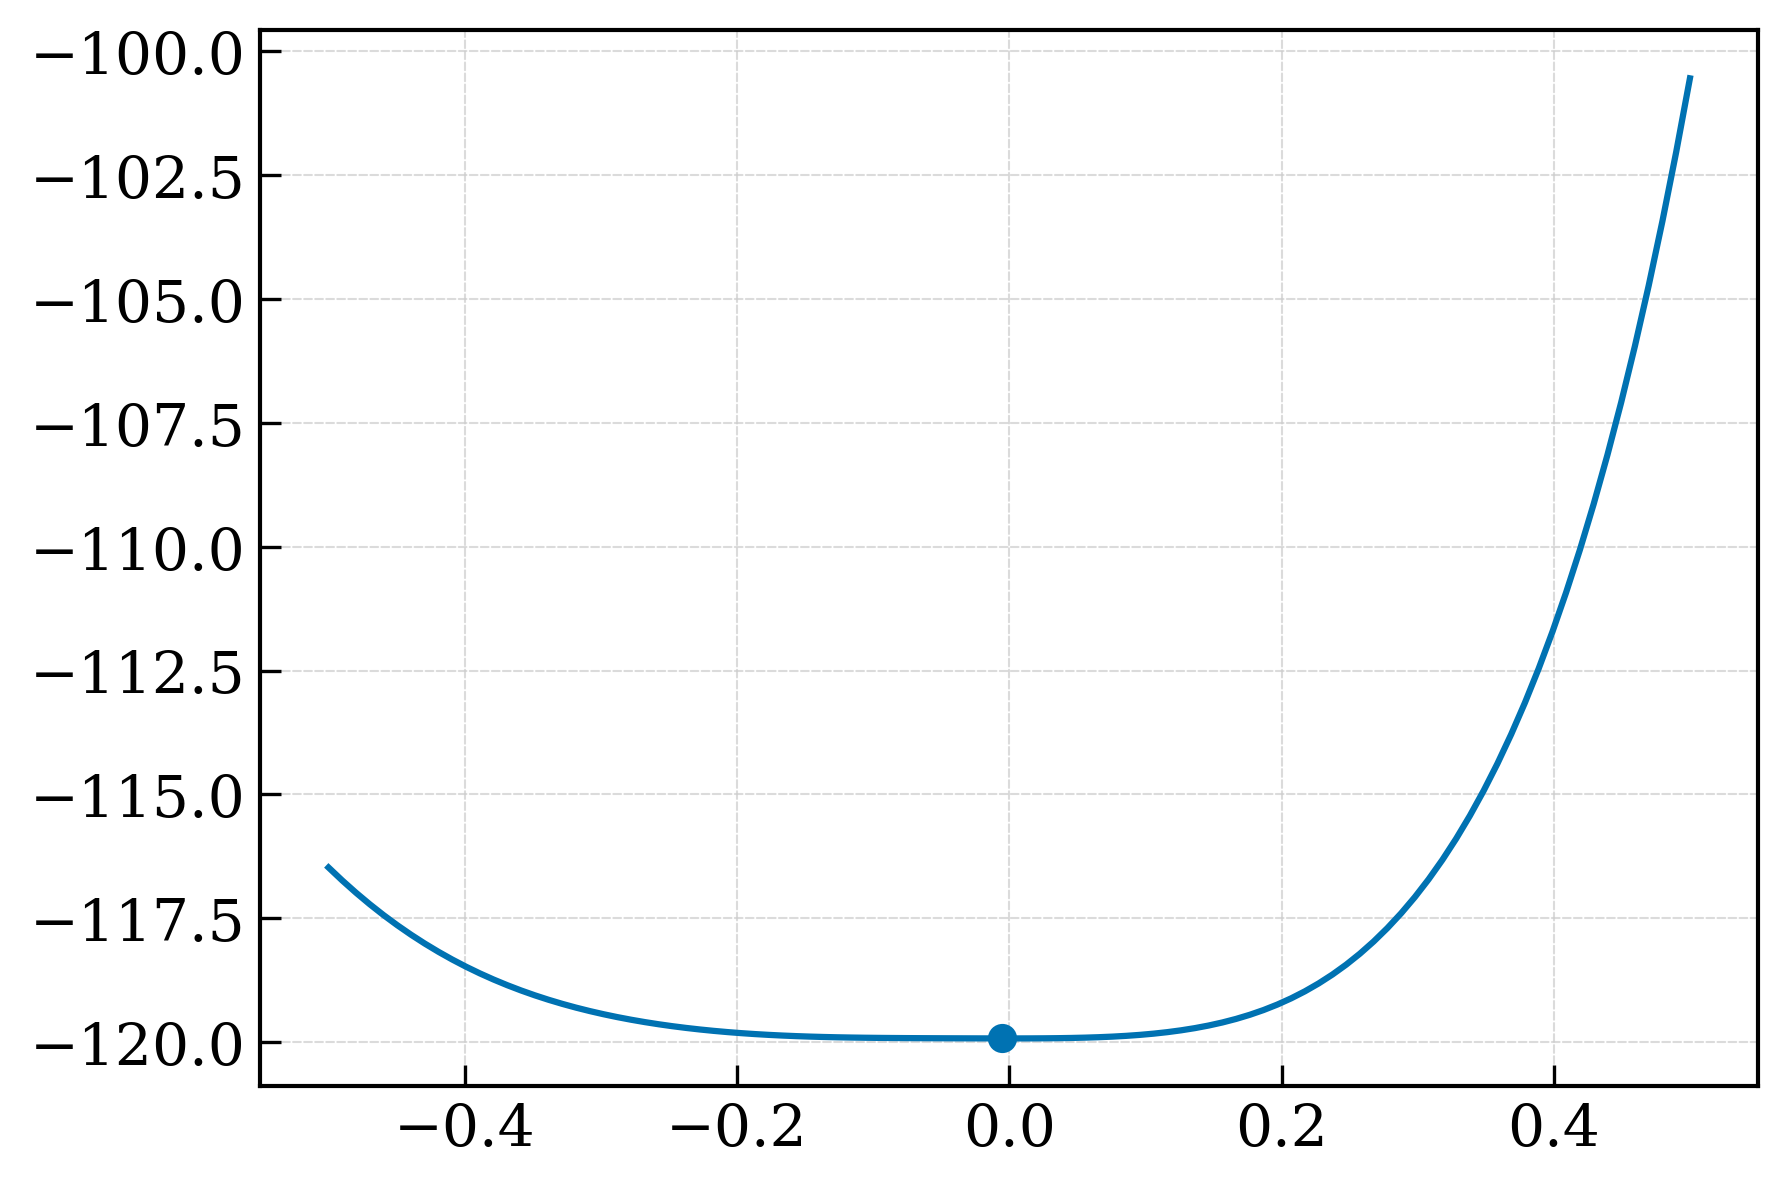

In [17]:
plt.plot(amplitudes, energies)
min_idx = np.argmin(energies)
mine = energies[min_idx]
mina = amplitudes[min_idx]
plt.scatter(mina, mine)

In [18]:
view(supercells, viewer = "ngl")  

In [46]:
from ase.io import write
write("supercells.extxyz", supercells)

In [19]:
supercells[-1].positions - supercells[0].positions

array([[ 0.40089186,  0.23145502,  0.        ],
       [-0.40089186, -0.23145502,  0.        ],
       [ 0.        , -0.46291005,  0.        ],
       [ 0.23145502, -0.40089186,  0.        ],
       [-0.40089186,  0.23145502,  0.        ],
       [ 0.16943684,  0.63234689,  0.        ],
       [ 0.        , -0.46291005,  0.        ],
       [ 0.23145502, -0.40089186,  0.        ],
       [-0.40089186,  0.23145502,  0.        ],
       [ 0.16943684,  0.63234689,  0.        ],
       [ 0.40089186,  0.23145502,  0.        ],
       [-0.40089186, -0.23145502,  0.        ],
       [-0.40089186,  0.23145502,  0.        ],
       [ 0.16943684,  0.63234689,  0.        ],
       [ 0.40089186,  0.23145502,  0.        ],
       [-0.40089186, -0.23145502,  0.        ],
       [ 0.        , -0.46291005,  0.        ],
       [ 0.23145502, -0.40089186,  0.        ]])

In [20]:
positions = np.array([supercells[i].positions for i in range(len(supercells))])